In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import math
import random
import seaborn as sns
import matplotlib.pyplot as plt
# Sirve para medir la velocidad de una función
import time
%load_ext line_profiler
import sys
sys.path.insert(1, '/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Codigos/Funciones_utiles')
import funciones_aux_bootstrap as fab

Este es un bootstrap (bayesiano) de votos directo (suponiendo que se pudieran muestrear los votos).

In [4]:
# Importamos los datos para el análisis
df_act_yuc_i=pd.read_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Base elecciones analsis/base_elecciones_yuc_analsis.csv", index_col=0)
df_act_yuc_i

,ID ESTADO,NOMBRE ESTADO,DISTRITO,SECCION,CASILLA,ID CASILLA,ESTATUS ACTA,PAN,PRI,PRD,...,CANDIDATOS NO REGISTRADOS,VOTOS NULOS,LISTA NOMINAL,TOTAL,PARTICIPACIÓN,JOAQUIN_DIAZ_MENA,RENAN_BARRERA_CONCHA,VIDA_ARAVARI_GOMEZ_HERRERA,YAMIL_JASMIN_LOPEZ_MANRIQUE,VOTOS_NULOS_CAND_NO_REGIS
0,31,YUCATÁN,12,1,'0001B1,1,COMPUTADA,171.0,107.0,3.0,...,0.0,12.0,596.0,532.0,0.892617,209.0,290.0,18.0,3.0,12.0
1,31,YUCATÁN,12,1,'0001C1,2,COMPUTADA,177.0,104.0,0.0,...,0.0,11.0,596.0,547.0,0.917785,208.0,299.0,29.0,0.0,11.0
2,31,YUCATÁN,12,1,'0001C2,3,COMPUTADA,176.0,100.0,1.0,...,0.0,13.0,595.0,542.0,0.910924,228.0,289.0,11.0,1.0,13.0
3,31,YUCATÁN,12,2,'0002B1,4,COMPUTADA,46.0,33.0,2.0,...,0.0,3.0,174.0,162.0,0.931034,71.0,79.0,7.0,2.0,3.0
4,31,YUCATÁN,12,4,'0004B1,6,COMPUTADA,110.0,96.0,7.0,...,0.0,14.0,550.0,513.0,0.932727,275.0,207.0,10.0,7.0,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2836,31,YUCATÁN,3,1195,'1195V1,2967,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,2.0,0.000000,0.0,2.0,0.0,0.0,0.0
2837,31,YUCATÁN,5,1197,'1197V1,2969,COMPUTADA,2.0,1.0,0.0,...,0.0,0.0,0.0,5.0,0.000000,2.0,3.0,0.0,0.0,0.0
2838,31,YUCATÁN,8,1199,'1199V1,2971,COMPUTADA,2.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.000000,1.0,2.0,0.0,0.0,0.0
2839,31,YUCATÁN,9,1200,'1200V1,2972,COMPUTADA,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.000000,1.0,0.0,0.0,0.0,0.0


In [5]:
# Datos reales de la proporción
prop_reales=df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum()/df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum()
prop_reales

JOAQUIN_DIAZ_MENA              0.515125
RENAN_BARRERA_CONCHA           0.421366
VIDA_ARAVARI_GOMEZ_HERRERA     0.036792
YAMIL_JASMIN_LOPEZ_MANRIQUE    0.005249
VOTOS_NULOS_CAND_NO_REGIS      0.021467
dtype: float64

## Sin estratificar

In [24]:
def bootstrap_votos_dir_simple(df, num_boot: int=1000, n_vot_mue=2000):

    est_punt_list=[]

    inter_list=[]

    # Número total de votos
    n_votos=int(df[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum())

    # Base con solo los votos de los candidatos
    df_cand=np.array(df[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum(0).astype(int))

    # Semilla para las muestras de la Dirichlet
    rng = np.random.default_rng()

    # Semilla para los conteos de votos (eventualmente se tiene que mover adentro del for para que sea reproducible el código)
    rng_2 = np.random.default_rng()

    for i in range(num_boot):

        # Votos por candidato en la muestra
        #n_votos_cand=df_stra_sam.sum(0).astype(int)
 
        # Muestra de votos (en este caso son 2000)
        # Lo correcto es utilizar la distribución hipergeométrica multivariada.
        votos_subm=rng.multivariate_hypergeometric(colors=df_cand, nsample=n_vot_mue)

        # Los pesos de la distribución Dirichlet
        pesos_bootstrap=rng.dirichlet(votos_subm, 1000)

        # Simulamos las 1000 poblaciones de votos
        votos_sim=rng_2.multinomial(n=n_votos,  pvals=pesos_bootstrap)

        # Obtenemos las proporciones de los votos
        array_res=(votos_sim)/n_votos

        # Los valores de los intervalos de probabilidad lower y upper
        inter_prob=np.concatenate((np.apply_along_axis(fab.inter_prob_l, axis=0, arr=array_res),np.apply_along_axis(fab.inter_prob_u, axis=0, arr=array_res)))
        
        # Estimaciones puntuales
        est_puntual=array_res.mean(0)

        # Guardamos las estimaciones puntuales
        est_punt_list.append(est_puntual)

        # Guardamos los intervalos
        inter_list.append(inter_prob)
        #print(i)
        
    
    # Todas las estimaciones puntuales
    array_est_punt=np.array(est_punt_list)

    array_inter_prob=np.array(inter_list)

    return array_inter_prob,array_est_punt


In [29]:
# Boostrap por votos
inter_prob_v, est_punt_v=bootstrap_votos_dir_simple(df_act_yuc_i, num_boot=1000, n_vot_mue=2000)

In [6]:
# Para medir cuanto tiempo se tarda en correr en promedio
%timeit bootstrap_votos_dir_simple(df_act_yuc_i, num_boot=1000, n_vot_mue=5000)

789 ms ± 1.93 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [30]:
# Guardamos las bases
df_metr_boot_v, df_error_max_v, df_can_cob_v = fab.metricas_bootstrap(prop_reales, inter_prob_v, est_punt_v, porcenta_tama=2000)

In [31]:
df_can_cob_v

,Candidato,Numero_total_cob,Cobertura,Porcenta_tama
0,JOAQUIN_DIAZ_MENA,940,0.940,2000
1,RENAN_BARRERA_CONCHA,938,0.938,2000
2,VIDA_ARAVARI_GOMEZ_HERRERA,947,0.947,2000
3,VOTOS_NULOS_CAND_NO_REGIS,937,0.937,2000
4,YAMIL_JASMIN_LOPEZ_MANRIQUE,943,0.943,2000


In [11]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c_v=df_metr_boot_v.drop(columns="Cobertura").merge(df_can_cob_v[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c_v

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.500995,0.529623,0.028628,0.515259,0.515125,JOAQUIN_DIAZ_MENA,0.000134,10000,0.947
1,2,0.494711,0.523046,0.028335,0.508798,0.515125,JOAQUIN_DIAZ_MENA,0.006327,10000,0.947
2,3,0.497914,0.526520,0.028606,0.511856,0.515125,JOAQUIN_DIAZ_MENA,0.003269,10000,0.947
3,4,0.501948,0.528280,0.026332,0.515059,0.515125,JOAQUIN_DIAZ_MENA,0.000067,10000,0.947
4,5,0.498062,0.526203,0.028142,0.511799,0.515125,JOAQUIN_DIAZ_MENA,0.003327,10000,0.947
...,...,...,...,...,...,...,...,...,...,...
4995,996,0.015385,0.023121,0.007736,0.018949,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.002518,10000,0.953
4996,997,0.016824,0.024701,0.007877,0.020561,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000906,10000,0.953
4997,998,0.016257,0.023481,0.007224,0.019783,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001684,10000,0.953
4998,999,0.018784,0.026419,0.007635,0.022429,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000962,10000,0.953


In [9]:
# Candidato con intervalo más largo
df_inter_lar_v=df_metr_boot_v.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar_v["Porcenta_tama"]=250
candidato_mas_largo_v=df_inter_lar_v[df_inter_lar_v["Longitud_intervalo"]==df_inter_lar_v["Longitud_intervalo"].max()]["Candidato"].values[0]
df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_mas_largo_v]["Longitud_intervalo"].describe()

count    1000.000000
mean        0.027648
std         0.000841
min         0.025079
25%         0.027056
50%         0.027637
75%         0.028185
max         0.030898
Name: Longitud_intervalo, dtype: float64

In [10]:
# Candidato con intervalo más largo
df_inter_lar_v=df_metr_boot_v.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar_v["Porcenta_tama"]=250
candidato_mas_largo_v=df_inter_lar_v[df_inter_lar_v["Longitud_intervalo"]==df_inter_lar_v["Longitud_intervalo"].max()]["Candidato"].values[0]

In [11]:
# Candidato con menor cobertura
candidato_cober_men_v=df_can_cob_v[df_can_cob_v["Cobertura"]==df_can_cob_v["Cobertura"].min()]["Candidato"].values[0]

In [12]:
df_error_max_v.describe(percentiles=[0.025,0.975])

,Num_bootstrap,Error_max,Porcenta_tama
count,1000.000000,1000.000000,1000.0
mean,500.500000,0.007035,10000.0
std,288.819436,0.004098,0.0
min,1.000000,0.000635,10000.0
2.5%,25.975000,0.001487,10000.0
50%,500.500000,0.006334,10000.0
97.5%,975.025000,0.016687,10000.0
max,1000.000000,0.023001,10000.0


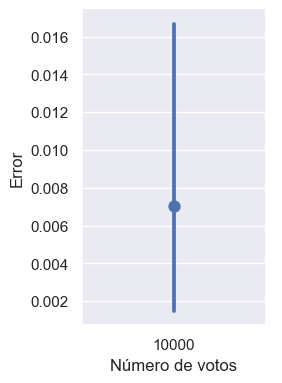

In [13]:
sns.set_theme();
ax = sns.catplot(
    data=df_error_max_v, x="Porcenta_tama", y="Error_max",
    kind="point", height=4, aspect=.7, errorbar='pi'
);
ax.set(xlabel='Número de votos', ylabel='Error');

In [14]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c_v=df_metr_boot_v.drop(columns="Cobertura").merge(df_can_cob_v[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c_v

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.497788,0.525088,0.027300,0.511023,0.515125,JOAQUIN_DIAZ_MENA,0.004103,10000,0.950
1,2,0.489126,0.517240,0.028115,0.503117,0.515125,JOAQUIN_DIAZ_MENA,0.012008,10000,0.950
2,3,0.495621,0.523856,0.028235,0.509452,0.515125,JOAQUIN_DIAZ_MENA,0.005674,10000,0.950
3,4,0.493985,0.519382,0.025397,0.506393,0.515125,JOAQUIN_DIAZ_MENA,0.008733,10000,0.950
4,5,0.502100,0.530255,0.028155,0.516086,0.515125,JOAQUIN_DIAZ_MENA,0.000961,10000,0.950
...,...,...,...,...,...,...,...,...,...,...
4995,996,0.019484,0.027617,0.008133,0.023237,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001770,10000,0.942
4996,997,0.017430,0.025346,0.007915,0.021333,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000134,10000,0.942
4997,998,0.016878,0.024904,0.008027,0.020775,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000692,10000,0.942
4998,999,0.018976,0.026800,0.007824,0.022785,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.001318,10000,0.942


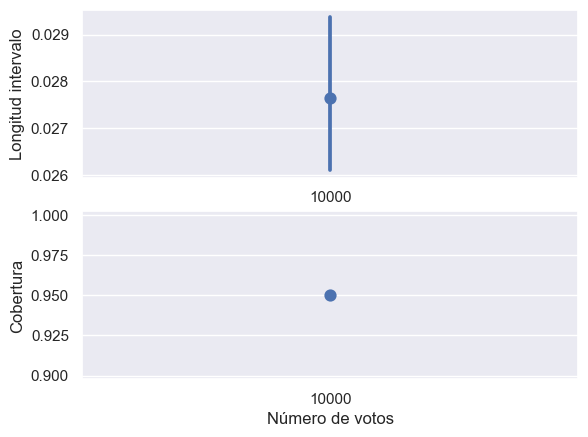

In [15]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_mas_largo_v], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi',ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_mas_largo_v].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Número de votos', ylabel='Longitud intervalo');
ax_2.set(xlabel='Número de votos', ylabel='Cobertura');


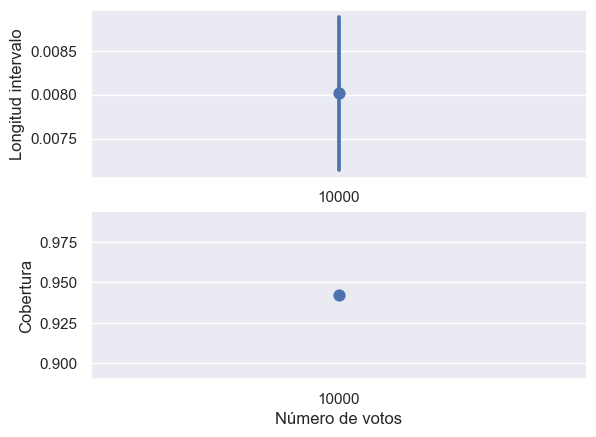

In [16]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_cober_men_v], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi', ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_cober_men_v].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Número de votos', ylabel='Longitud intervalo');
ax_2.set(xlabel='Número de votos', ylabel='Cobertura');

## Bootstraps con distintas muestras de votos

In [ ]:
# Probamos distintos valores de tamaño de la muestra de las casillas y la submuestra de votos
#muestra_votos = [500, 1000, 1500, 2000, 3000, 4000, 5000]
# Edición especial con 10000 y 20000 y quitando 1500 y 3000
muestra_votos = [500, 1000, 2000, 5000, 10000, 20000]

# Dataframe donde se guardará todo
df_boostraps_votos_se=pd.DataFrame()

# Contador para el for
k=0

for mv in muestra_votos:
    
        # Boostrap por votos (sin estratificar)
        inter_prob, est_punt=bootstrap_votos_dir_simple(df_act_yuc_i, num_boot=1000, n_vot_mue=mv)
        # Calculamos las métricas
        df_metr_boot, df_error_max, df_can_cob= fab.metricas_bootstrap(prop_reales, inter_prob, est_punt, porcenta_tama=mv)

        # Los valores de las muestra y submuestras
        df_boostraps_votos_se.loc[k,"Tamaño_muestra_votos"]= mv

        # Las métricas para el error máximo
        df_boostraps_votos_se.loc[k,["Error_maximo_q_025","Error_maximo_mediana","Error_maximo_q_975"]]=df_error_max["Error_max"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato que tenga intervalos más largos (en promedio)
        candidato_int_m_l_c=df_metr_boot.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()["Candidato"].values[0]
        # Candidato con el intervalos más grandes
        df_boostraps_votos_se.loc[k, "Intervalo_M_grande_candidato_nom"]=candidato_int_m_l_c
        # Cobertura del candidato con el intervalos más grandes
        df_boostraps_votos_se.loc[k, ["Intervalo_M_grande_candidato_cob"]]=df_can_cob[df_can_cob["Candidato"]==candidato_int_m_l_c]["Cobertura"].values[0]
        # Las métricas del candidato con los intervalos más grandes
        df_boostraps_votos_se.loc[k,["Intervalo_M_grande_inter_q_025","Intervalo_M_grande_inter_mediana","Intervalo_M_grande_inter_q_975"]]=df_metr_boot[df_metr_boot["Candidato"]==candidato_int_m_l_c]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato con la menor cobertura
        # Candidato con menor cobertura
        candidato_cober_men=df_can_cob[df_can_cob["Cobertura"]==df_can_cob["Cobertura"].min()]["Candidato"].values[0]

        # Candidato con el intervalos más grandes
        df_boostraps_votos_se.loc[k, "Cobertura_m_candidato_nom"]=candidato_cober_men
        # Cobertura del candidato con menor cobertura
        df_boostraps_votos_se.loc[k, ["Cobertura_m_candidato"]]=df_can_cob[df_can_cob["Candidato"]==candidato_cober_men]["Cobertura"].values[0]
        # Las métricas del candidato con la menor cobertura
        df_boostraps_votos_se.loc[k,["Cobertura_m_inter_q_025","Cobertura_m_inter_mediana","Cobertura_m_inter_q_975"]]=df_metr_boot[df_metr_boot["Candidato"]==candidato_cober_men]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        
        # Coberturas de los candidatos en el bootstrap 
        df_boostraps_votos_se.loc[k, ["Cob_JOAQUIN_DIAZ_MENA","Cob_RENAN_BARRERA_CONCHA","Cob_VIDA_ARAVARI_GOMEZ_HERRERA","Cob_VOTOS_NULOS_CAND_NO_REGIS","Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"]]=df_can_cob.sort_values(by="Candidato")["Cobertura"].to_list()

        k=k+1
        
        print("Muestra casillas:", mv)

Muestra casillas: 500
Muestra casillas: 1000
Muestra casillas: 2000
Muestra casillas: 4000
Muestra casillas: 5000
Muestra casillas: 10000
Muestra casillas: 20000


In [19]:
df_boostraps_votos_se

,Tamaño_muestra_votos,Error_maximo_q_025,Error_maximo_mediana,Error_maximo_q_975,Intervalo_M_grande_candidato_nom,Intervalo_M_grande_candidato_cob,Intervalo_M_grande_inter_q_025,Intervalo_M_grande_inter_mediana,Intervalo_M_grande_inter_q_975,Cobertura_m_candidato_nom,Cobertura_m_candidato,Cobertura_m_inter_q_025,Cobertura_m_inter_mediana,Cobertura_m_inter_q_975,Cob_JOAQUIN_DIAZ_MENA,Cob_RENAN_BARRERA_CONCHA,Cob_VIDA_ARAVARI_GOMEZ_HERRERA,Cob_VOTOS_NULOS_CAND_NO_REGIS,Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE
0,500.0,0.005325,0.018713,0.050710,JOAQUIN_DIAZ_MENA,0.948,0.082236,0.086988,0.092498,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.896,0.000000,0.010926,0.019694,0.948,0.953,0.942,0.935,0.896
1,1000.0,0.003413,0.013745,0.038806,JOAQUIN_DIAZ_MENA,0.942,0.058337,0.061663,0.065235,JOAQUIN_DIAZ_MENA,0.942,0.058337,0.061663,0.065235,0.942,0.947,0.951,0.949,0.944
2,2000.0,0.002571,0.009455,0.026092,JOAQUIN_DIAZ_MENA,0.956,0.041367,0.043646,0.046281,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.928,0.003896,0.006203,0.008176,0.956,0.955,0.933,0.937,0.928
3,4000.0,0.001755,0.006691,0.018611,JOAQUIN_DIAZ_MENA,0.947,0.028923,0.030810,0.032632,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.929,0.003315,0.004431,0.005410,0.947,0.952,0.959,0.956,0.929
4,5000.0,0.001618,0.006176,0.017469,JOAQUIN_DIAZ_MENA,0.945,0.026112,0.027606,0.029296,VIDA_ARAVARI_GOMEZ_HERRERA,0.939,0.009458,0.010381,0.011407,0.945,0.943,0.939,0.947,0.940
5,10000.0,0.001053,0.004442,0.012669,JOAQUIN_DIAZ_MENA,0.947,0.018470,0.019586,0.020683,RENAN_BARRERA_CONCHA,0.937,0.018246,0.019369,0.020538,0.947,0.937,0.947,0.944,0.950
6,20000.0,0.000776,0.003145,0.008309,JOAQUIN_DIAZ_MENA,0.958,0.013021,0.013860,0.014674,VIDA_ARAVARI_GOMEZ_HERRERA,0.942,0.004907,0.005239,0.005609,0.958,0.958,0.942,0.942,0.951


In [20]:
# Guardamos en un csv
df_boostraps_votos_se.to_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Bootstrap votos/Directo/Distintas_muestras_submuestras_bootstrap_votos_dir_sin_est_3_ed_e.csv")

## Estratificado

In [6]:
# Versión función
def boot_votos_dir_estratificado(df_act_yuc_i, num_boot: int=1000, n_vot_mue=2000):

    # Listas auxiliares para guardar los datos
    est_punt_list=[]

    inter_list=[]

    # Cuantas votos hay por distrito
    array_frec_est=np.array(np.array(df_act_yuc_i.groupby('DISTRITO').agg({'TOTAL':'sum'}).reset_index(drop=True).astype(int)["TOTAL"]))

    # Guardamos en un numpy array el dataframe como los votos y el distrito de toda la base
    array_muest=np.array(df_act_yuc_i[["DISTRITO","JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]])

    # Corrección porque el muestreo estratificado es de votos
    # Porcentaje del total de votos por estrato (distrito)
    array_pesos_normalizados_dist=np.array(df_act_yuc_i.groupby('DISTRITO').agg({'TOTAL':'sum'}).div(df_act_yuc_i["TOTAL"].sum()).sort_index()["TOTAL"])

    # Los valores distintos de los distritos
    val_dist=df_act_yuc_i["DISTRITO"].sort_values().unique()

    # Número de poblaciones
    n_boot=1000

    # Semilla para las muestras de la Dirichlet
    rng = np.random.default_rng()

    # Semilla para las muestras de la Dirichlet
    rng_2 = np.random.default_rng()

    for i in range(num_boot):

        # Obtenemos los totales de las proporciones para cada estrato (distrito)
        totales_prop_est=fab.obtener_totales(array_pesos_normalizados_dist, n_vot_mue).astype(int)

        # Los porcentajes de cada distrito de toda la muestra de votoss
        array_pesos_normalizados_mue=totales_prop_est/totales_prop_est.sum()

        # Muestra de votos por distrito (estrato)
        # Lo correcto es utilizar la distribución hipergeométrica multivariada.
        # Puesto que, se esta haciendo muestreo sin reemplazo y si utilizas la multinomial es muestreo con reemplazo.
        votos_subm_d=[rng.multivariate_hypergeometric(colors=array_muest[array_muest[:,0]==val][:,1:].sum(0).astype(int), nsample=totales_prop_est[val-1]) for val in val_dist]

        # Vector de pesos de la distribución Dirichlet
        # Hay que arreglar la función para que pueda aceptar valores con alfa igual a cero (que tengan probabilidad 0)
        vectores_dir=[fab.f_a(xi,n_boot) for xi in votos_subm_d]


        # Donde se van a guardar los resultados
        array_res=np.zeros((n_boot,5))

        # Completamos la muestra mediante el bootstrap bayesiano en cada estrato
        for k in val_dist:
            
            # Total de votos de la muestra simulada (utilizando una multinomial)
            votos_sim=rng_2.multinomial(n=array_frec_est[k-1],  pvals=vectores_dir[k-1])

            # Guardamos todo en un array con las estimaciones (se van sumando las iteraciones para alcnazar el 100%)
            array_res=array_res+(votos_sim/votos_sim.sum(1)[0]*array_pesos_normalizados_mue[k-1])

        # Los valores de los intervalos de probabilidad lower y upper
        inter_prob=np.concatenate((np.apply_along_axis(fab.inter_prob_l, axis=0, arr=array_res),np.apply_along_axis(fab.inter_prob_u, axis=0, arr=array_res)))

        # Estimaciones puntuales (del bootstrap)
        est_puntual=array_res.mean(0)

        # Guardamos las estimaciones puntuales
        est_punt_list.append(est_puntual)

        # Guardamos los intervalos
        inter_list.append(inter_prob)
    
    # Todas las estimaciones puntuales
    array_est_punt=np.array(est_punt_list)

    array_inter_prob=np.array(inter_list)
    
    return array_inter_prob,array_est_punt


In [11]:
inter_prob_v_est, est_punt_v_est=boot_votos_dir_estratificado(df_act_yuc_i, num_boot=1000, n_vot_mue=2000)

In [12]:
# Para medir cuanto tiempo se tarda en correr en promedio
#%timeit boot_votos_dir_estratificado(df_act_yuc_i, num_boot=1000, n_vot_mue=2500)

In [8]:
# Cálculamos las métricas
df_metr_boot_v_est, df_error_max_v_est, df_can_cob_v_est = fab.metricas_bootstrap(prop_reales, inter_prob_v_est, est_punt_v_est, porcenta_tama=2000)

In [9]:
df_can_cob_v_est

,Candidato,Numero_total_cob,Cobertura,Porcenta_tama
0,JOAQUIN_DIAZ_MENA,951,0.951,2000
1,RENAN_BARRERA_CONCHA,944,0.944,2000
2,VIDA_ARAVARI_GOMEZ_HERRERA,940,0.940,2000
3,VOTOS_NULOS_CAND_NO_REGIS,951,0.951,2000
4,YAMIL_JASMIN_LOPEZ_MANRIQUE,928,0.928,2000


In [10]:
df_can_cob_v_est["Numero_total_cob"].sum()

np.int64(4714)

In [8]:
# Candidato con intervalo más largo
df_inter_lar_v_est=df_metr_boot_v_est.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar_v_est["Porcenta_tama"]=250
candidato_mas_largo_v_est=df_inter_lar_v_est[df_inter_lar_v_est["Longitud_intervalo"]==df_inter_lar_v_est["Longitud_intervalo"].max()]["Candidato"].values[0]

In [9]:
# Candidato con menor cobertura
candidato_cober_men_v_est=df_can_cob_v_est[df_can_cob_v_est["Cobertura"]==df_can_cob_v_est["Cobertura"].min()]["Candidato"].values[0]

In [10]:
df_error_max_v_est.describe(percentiles=[0.025,0.975])

,Num_bootstrap,Error_max,Porcenta_tama
count,2000.000000,2000.000000,2000.0
mean,1000.500000,0.010481,2000.0
std,577.494589,0.006044,0.0
min,1.000000,0.000828,2000.0
2.5%,50.975000,0.002594,2000.0
50%,1000.500000,0.009139,2000.0
97.5%,1950.025000,0.024384,2000.0
max,2000.000000,0.037068,2000.0


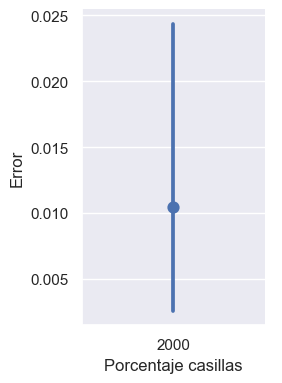

In [11]:
sns.set_theme();
ax = sns.catplot(
    data=df_error_max_v_est, x="Porcenta_tama", y="Error_max",
    kind="point", height=4, aspect=.7, errorbar='pi'
);
ax.set(xlabel='Porcentaje casillas', ylabel='Error');

In [12]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c_v_est=df_metr_boot_v_est.drop(columns="Cobertura").merge(df_can_cob_v_est[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c_v_est

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.480728,0.524523,0.043796,0.503555,0.515125,JOAQUIN_DIAZ_MENA,0.011571,2000,0.955
1,2,0.480728,0.524523,0.043796,0.503555,0.515125,JOAQUIN_DIAZ_MENA,0.011571,2000,0.955
2,3,0.509021,0.550958,0.041936,0.529556,0.515125,JOAQUIN_DIAZ_MENA,0.014431,2000,0.955
3,4,0.509021,0.550958,0.041936,0.529556,0.515125,JOAQUIN_DIAZ_MENA,0.014431,2000,0.955
4,5,0.480671,0.522623,0.041952,0.501641,0.515125,JOAQUIN_DIAZ_MENA,0.013485,2000,0.955
...,...,...,...,...,...,...,...,...,...,...
9995,1996,0.017547,0.030774,0.013227,0.023656,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.002189,2000,0.942
9996,1997,0.012498,0.023966,0.011468,0.018088,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.003379,2000,0.942
9997,1998,0.012498,0.023966,0.011468,0.018088,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.003379,2000,0.942
9998,1999,0.019119,0.032700,0.013581,0.025455,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.003988,2000,0.942


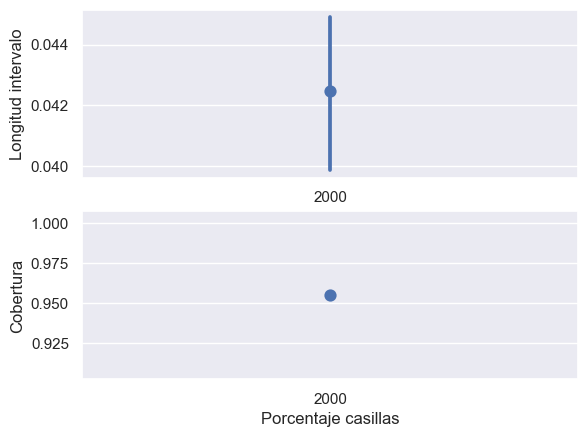

In [13]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_mas_largo_v_est], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi',ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_mas_largo_v_est].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');


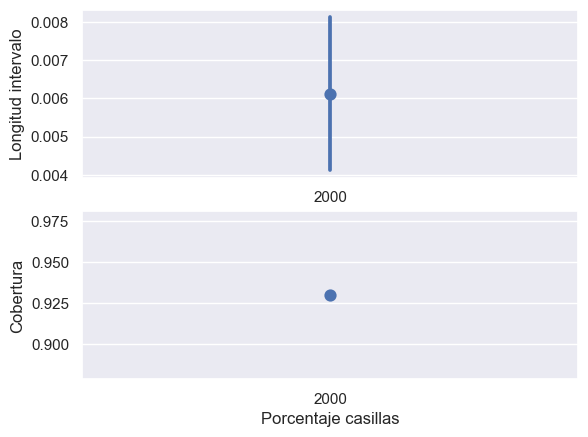

In [14]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_cober_men_v_est], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi', ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_cober_men_v_est].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');

## Bootstraps con distintas muestras de votos

In [ ]:
# Probamos distintos valores de tamaño de la muestra de las casillas y la submuestra de votos
#muestra_votos = [500, 1000, 1500, 2000, 3000, 4000, 5000]
# Edición especial con 10000 y 20000 y quitando 1500 y 3000

muestra_votos = [500, 1000, 2000, 5000, 10000, 20000]

# Dataframe donde se guardará todo
df_boostraps_votos_est=pd.DataFrame()

# Contador para el for
k=0

for mv in muestra_votos:
        # Para medir cuanto tiempo se tarda en correr
        loop_time = time.time()
    
        # Boostrap por votos (sin estratificar)
        inter_prob_v_est, est_punt_v_est=boot_votos_dir_estratificado(df_act_yuc_i, num_boot=1000, n_vot_mue=mv)
        # Calculamos las métricas
        df_metr_boot_c_v_est, df_error_max_v_est, df_can_cob_v_est=fab.metricas_bootstrap(prop_reales, inter_prob_v_est, est_punt_v_est, porcenta_tama=mv)

        # Los valores de las muestra y submuestras
        df_boostraps_votos_est.loc[k,"Tamaño_muestra_votos"]= mv

        # Las métricas para el error máximo
        df_boostraps_votos_est.loc[k,["Error_maximo_q_025","Error_maximo_mediana","Error_maximo_q_975"]]=df_error_max_v_est["Error_max"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato que tenga intervalos más largos (en promedio)
        candidato_int_m_l_c_est=df_metr_boot_c_v_est.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()["Candidato"].values[0]
        # Candidato con el intervalos más grandes
        df_boostraps_votos_est.loc[k, "Intervalo_M_grande_candidato_nom"]=candidato_int_m_l_c_est
        # Cobertura del candidato con el intervalos más grandes
        df_boostraps_votos_est.loc[k, ["Intervalo_M_grande_candidato_cob"]]=df_can_cob_v_est[df_can_cob_v_est["Candidato"]==candidato_int_m_l_c_est]["Cobertura"].values[0]
        # Las métricas del candidato con los intervalos más grandes
        df_boostraps_votos_est.loc[k,["Intervalo_M_grande_inter_q_025","Intervalo_M_grande_inter_mediana","Intervalo_M_grande_inter_q_975"]]=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_int_m_l_c_est]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        # Calculamos el candidato con la menor cobertura
        # Candidato con menor cobertura
        candidato_cober_men_est=df_can_cob_v_est[df_can_cob_v_est["Cobertura"]==df_can_cob_v_est["Cobertura"].min()]["Candidato"].values[0]

        # Candidato con el intervalos más grandes
        df_boostraps_votos_est.loc[k, "Cobertura_m_candidato_nom"]=candidato_cober_men_est
        # Cobertura del candidato con menor cobertura
        df_boostraps_votos_est.loc[k, ["Cobertura_m_candidato"]]=df_can_cob_v_est[df_can_cob_v_est["Candidato"]==candidato_cober_men_est]["Cobertura"].values[0]
        # Las métricas del candidato con la menor cobertura
        df_boostraps_votos_est.loc[k,["Cobertura_m_inter_q_025","Cobertura_m_inter_mediana","Cobertura_m_inter_q_975"]]=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_cober_men_est]["Longitud_intervalo"].quantile([0.025,0.5,0.975]).to_list()

        
        # Coberturas de los candidatos en el bootstrap 
        df_boostraps_votos_est.loc[k, ["Cob_JOAQUIN_DIAZ_MENA","Cob_RENAN_BARRERA_CONCHA","Cob_VIDA_ARAVARI_GOMEZ_HERRERA","Cob_VOTOS_NULOS_CAND_NO_REGIS","Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE"]]=df_can_cob_v_est.sort_values(by="Candidato")["Cobertura"].to_list()

        k=k+1
        
        print("Muestra votos:", mv)
        print('Tiempo que tarda correr una iteración del for {}'.format((time.time() - loop_time)))  

Muestra votos: 500
Tiempo que tarda correr una iteración del for 8.192049980163574
Muestra votos: 1000
Tiempo que tarda correr una iteración del for 8.992564916610718
Muestra votos: 2000
Tiempo que tarda correr una iteración del for 10.12398910522461
Muestra votos: 4000
Tiempo que tarda correr una iteración del for 11.195926904678345
Muestra votos: 5000
Tiempo que tarda correr una iteración del for 10.980242013931274
Muestra votos: 10000
Tiempo que tarda correr una iteración del for 11.381348133087158
Muestra votos: 20000
Tiempo que tarda correr una iteración del for 11.62618088722229


In [15]:
df_boostraps_votos_est

,Tamaño_muestra_votos,Error_maximo_q_025,Error_maximo_mediana,Error_maximo_q_975,Intervalo_M_grande_candidato_nom,Intervalo_M_grande_candidato_cob,Intervalo_M_grande_inter_q_025,Intervalo_M_grande_inter_mediana,Intervalo_M_grande_inter_q_975,Cobertura_m_candidato_nom,Cobertura_m_candidato,Cobertura_m_inter_q_025,Cobertura_m_inter_mediana,Cobertura_m_inter_q_975,Cob_JOAQUIN_DIAZ_MENA,Cob_RENAN_BARRERA_CONCHA,Cob_VIDA_ARAVARI_GOMEZ_HERRERA,Cob_VOTOS_NULOS_CAND_NO_REGIS,Cob_YAMIL_JASMIN_LOPEZ_MANRIQUE
0,500.0,0.005109,0.018929,0.052839,JOAQUIN_DIAZ_MENA,0.943,0.076930,0.082137,0.087558,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.908,0.000000,0.010686,0.018696,0.943,0.933,0.937,0.934,0.908
1,1000.0,0.003542,0.013886,0.037790,JOAQUIN_DIAZ_MENA,0.937,0.055908,0.059334,0.063004,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.936,0.003769,0.008419,0.012048,0.937,0.958,0.941,0.945,0.936
2,2000.0,0.002648,0.009465,0.026610,JOAQUIN_DIAZ_MENA,0.948,0.039963,0.042453,0.045098,RENAN_BARRERA_CONCHA,0.937,0.039197,0.041771,0.044481,0.948,0.937,0.953,0.943,0.939
3,4000.0,0.001779,0.006524,0.018250,JOAQUIN_DIAZ_MENA,0.951,0.028404,0.030183,0.031938,VOTOS_NULOS_CAND_NO_REGIS,0.934,0.007808,0.008867,0.009982,0.951,0.950,0.938,0.934,0.939
4,5000.0,0.001834,0.006131,0.016236,JOAQUIN_DIAZ_MENA,0.953,0.025492,0.027036,0.028631,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.938,0.003113,0.003949,0.004753,0.953,0.951,0.946,0.956,0.938
5,10000.0,0.001178,0.004211,0.011513,JOAQUIN_DIAZ_MENA,0.952,0.018155,0.019206,0.020327,RENAN_BARRERA_CONCHA,0.941,0.017865,0.018950,0.020099,0.952,0.941,0.943,0.947,0.944
6,20000.0,0.000815,0.002939,0.008498,JOAQUIN_DIAZ_MENA,0.945,0.012894,0.013657,0.014501,YAMIL_JASMIN_LOPEZ_MANRIQUE,0.938,0.001775,0.002001,0.002232,0.945,0.943,0.950,0.941,0.938


In [17]:
# Guardamos en un csv
df_boostraps_votos_est.to_csv(r"/Users/damian/Documents/Tesis maestria/Bootstraps_codigos_bases/Bases/Bootstrap votos/Directo/Distintas_muestras_submuestras_bootstrap_votos_dir_estratificado_3_ed_e.csv")